Mounted at /content/drive
Loading: /content/drive/MyDrive/EarthEngine_ML_Data/raw_merged_dataset.csv
Columns: ['Region_ID', 'Date', 'lon', 'lat', 'ValidFrac_Land', 'WaterFrac_Valid', 'ValidPixCount', 'WaterPixCount', 'LandPixCount', 'WI_mean', 'NDWI_mean', 'DSWE_mean', 'system:index', 'Precip_mm', '.geo', 'rain_sum_7', 'rain_sum_15', 'rain_sum_30', 'rain_sum_60', 'rain_sum_90', 'rain_days_7']

Label summary
Y
0    1080
1     480
Name: count, dtype: int64
Positive rate: 0.3076923076923077
Baseline_DSWE == 0 fraction: 0.8666666666666667
Rows after cleaning: (1560, 10)
Sequence shape: (1365, 14, 7)
Sequence positive rate: 0.3054945054945055
Split sizes:
Train: (819, 14, 7) Val: (273, 14, 7) Test: (273, 14, 7)
Training RF...
Best validation threshold: 0.439
Validation F1: 0.8364

Test results
PR-AUC: 0.872680649670318
ROC-AUC: 0.9284083703233988
Brier: 0.1037830466293001
F1: 0.7730061349693251

Confusion matrix
[[173  17]
 [ 20  63]]

Classification report
              precision    recall

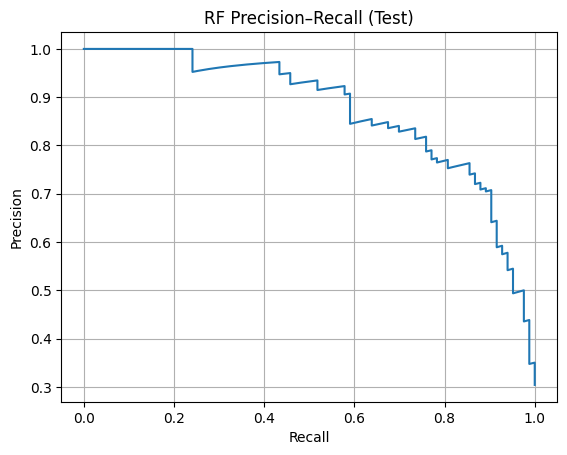

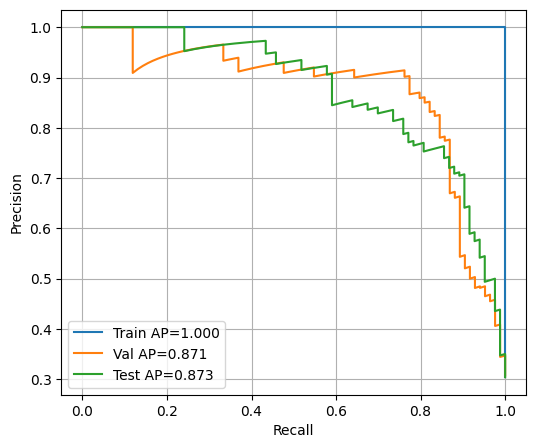

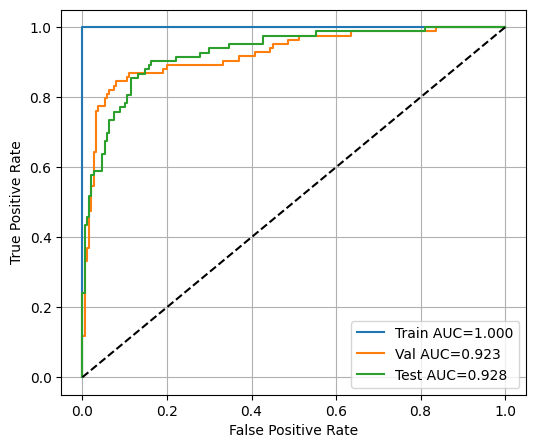

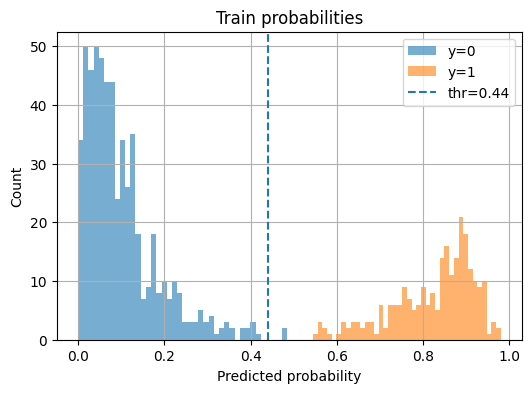

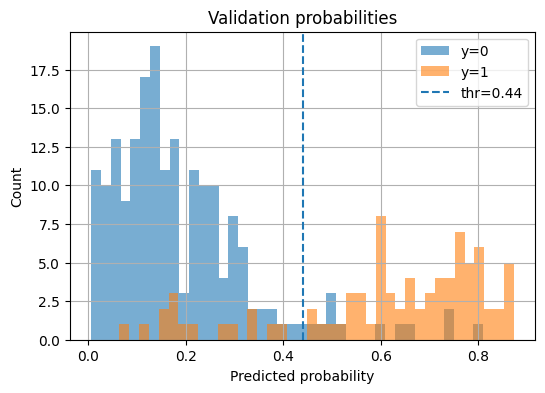

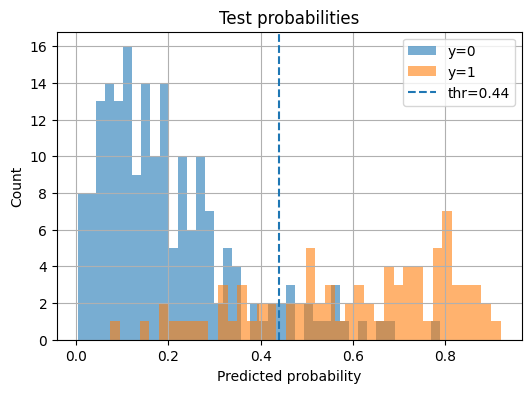

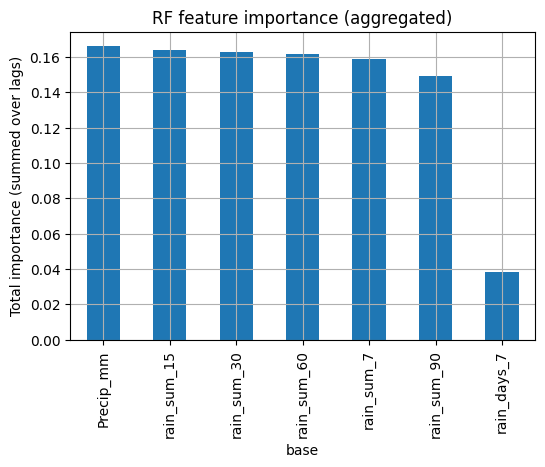

In [ ]:
# Random Forest
# No month_sin / month_cos
# Label: DSWE > (per-region median × ratio)

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    roc_auc_score, confusion_matrix, classification_report,
    f1_score, brier_score_loss
)

# ------------------------------------------------------------------
# Setup
# ------------------------------------------------------------------
drive.mount('/content/drive')

BASE_DIR   = "/content/drive/MyDrive/EarthEngine_ML_Data"
INPUT_FILE = os.path.join(BASE_DIR, "raw_merged_dataset.csv")

OUT_DIR = os.path.join(BASE_DIR, "rf_seq_outputs_match_lstm_label_v1")
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
SEQ_LEN = 14

FEATURES = [
    "Precip_mm",
    "rain_sum_7", "rain_sum_15", "rain_sum_30",
    "rain_sum_60", "rain_sum_90",
    "rain_days_7",
]

REGION_COL = "Region_ID"
DATE_COL   = "Date"

# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
print(f"Loading: {INPUT_FILE}")
df = pd.read_csv(INPUT_FILE)
print("Columns:", df.columns.tolist())

df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# ------------------------------------------------------------------
# Label construction (same logic as LSTM)
# ------------------------------------------------------------------
DSWE_COL = "DSWE_mean"
if DSWE_COL not in df.columns:
    raise ValueError("DSWE_mean not found in dataset")

df[DSWE_COL] = pd.to_numeric(df[DSWE_COL], errors="coerce")
df = df.dropna(subset=[DSWE_COL]).copy()

RATIO = 1.09
df["Baseline_DSWE"] = df.groupby(REGION_COL)[DSWE_COL].transform("median")

# strict '>' avoids trivial positives when baseline = 0
df["Y"] = (df[DSWE_COL] > (df["Baseline_DSWE"] * RATIO)).astype(int)

print("\nLabel summary")
print(df["Y"].value_counts())
print("Positive rate:", df["Y"].mean())
print("Baseline_DSWE == 0 fraction:", (df["Baseline_DSWE"] == 0).mean())

# ------------------------------------------------------------------
# Basic cleaning and ordering
# ------------------------------------------------------------------
required = [REGION_COL, DATE_COL, "Y"] + FEATURES
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df_model = df[required].dropna().copy()
df_model = df_model.sort_values([REGION_COL, DATE_COL])

print("Rows after cleaning:", df_model.shape)

# ------------------------------------------------------------------
# Sequence construction
# ------------------------------------------------------------------
def make_sequences(df, features, label_col, date_col, region_col, seq_len):
    X_out, y_out = [], []

    for _, g in df.groupby(region_col, sort=False):
        g = g.sort_values(date_col)
        Xv = g[features].to_numpy(dtype=np.float32)
        yv = g[label_col].to_numpy(dtype=np.int64)

        if len(g) < seq_len:
            continue

        for i in range(seq_len - 1, len(g)):
            X_out.append(Xv[i - seq_len + 1 : i + 1])
            y_out.append(yv[i])

    X = np.stack(X_out)
    y = np.array(y_out)
    return X, y

X_seq, y_seq = make_sequences(
    df_model, FEATURES, "Y", DATE_COL, REGION_COL, SEQ_LEN
)

print("Sequence shape:", X_seq.shape)
print("Sequence positive rate:", y_seq.mean())

# ------------------------------------------------------------------
# Train / validation / test split
# ------------------------------------------------------------------
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_seq, y_seq,
    test_size=0.40,
    stratify=y_seq,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp,
    test_size=0.50,
    stratify=y_tmp,
    random_state=RANDOM_STATE
)

print("Split sizes:")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ------------------------------------------------------------------
# Flatten sequences and scale
# ------------------------------------------------------------------
def flatten(X):
    return X.reshape(X.shape[0], -1)

scaler = StandardScaler()
X_train_fs = scaler.fit_transform(flatten(X_train))
X_val_fs   = scaler.transform(flatten(X_val))
X_test_fs  = scaler.transform(flatten(X_test))

# ------------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training RF...")
rf.fit(X_train_fs, y_train)

# ------------------------------------------------------------------
# Threshold selection on validation set
# ------------------------------------------------------------------
val_proba = rf.predict_proba(X_val_fs)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, val_proba)

f1s = (2 * prec * rec) / np.maximum(prec + rec, 1e-12)
best_idx = int(np.nanargmax(f1s))

best_thr = thr[best_idx - 1] if best_idx > 0 else 0.5
best_f1_val = f1s[best_idx]

print(f"Best validation threshold: {best_thr:.3f}")
print(f"Validation F1: {best_f1_val:.4f}")

# ------------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------------
test_proba = rf.predict_proba(X_test_fs)[:, 1]
test_pred  = (test_proba >= best_thr).astype(int)

print("\nTest results")
print("PR-AUC:", average_precision_score(y_test, test_proba))
print("ROC-AUC:", roc_auc_score(y_test, test_proba))
print("Brier:", brier_score_loss(y_test, test_proba))
print("F1:", f1_score(y_test, test_pred))

print("\nConfusion matrix")
print(confusion_matrix(y_test, test_pred))

print("\nClassification report")
print(classification_report(y_test, test_pred, digits=4))

# ------------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------------
import joblib

joblib.dump(rf, os.path.join(OUT_DIR, "rf_seq_model.joblib"))
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))

with open(os.path.join(OUT_DIR, "metrics.json"), "w") as f:
    json.dump({
        "dswe_col": DSWE_COL,
        "ratio": RATIO,
        "best_val_threshold": float(best_thr),
        "val_best_f1": float(best_f1_val),
        "test_pr_auc": float(average_precision_score(y_test, test_proba)),
        "test_roc_auc": float(roc_auc_score(y_test, test_proba)),
        "test_brier": float(brier_score_loss(y_test, test_proba)),
        "test_f1": float(f1_score(y_test, test_pred)),
        "features": FEATURES,
        "seq_len": SEQ_LEN,
        "label_method": "per_region_median_times_ratio_strict_gt",
    }, f, indent=2)

print(f"Saved outputs to {OUT_DIR}")

# ------------------------------------------------------------------
# Plots
# ------------------------------------------------------------------
prec_t, rec_t, _ = precision_recall_curve(y_test, test_proba)
plt.figure()
plt.plot(rec_t, prec_t)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("RF Precision–Recall (Test)")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
for name, yt, pb in [
    ("Train", y_train, rf.predict_proba(X_train_fs)[:,1]),
    ("Val",   y_val,   val_proba),
    ("Test",  y_test,  test_proba),
]:
    p, r, _ = precision_recall_curve(yt, pb)
    ap = average_precision_score(yt, pb)
    plt.plot(r, p, label=f"{name} AP={ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,5))
for name, yt, pb in [
    ("Train", y_train, rf.predict_proba(X_train_fs)[:,1]),
    ("Val",   y_val,   val_proba),
    ("Test",  y_test,  test_proba),
]:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(yt, pb)
    auc = roc_auc_score(yt, pb)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

def plot_prob_hist(y, proba, title):
    plt.figure(figsize=(6,4))
    plt.hist(proba[y==0], bins=40, alpha=0.6, label="y=0")
    plt.hist(proba[y==1], bins=40, alpha=0.6, label="y=1")
    plt.axvline(best_thr, linestyle="--", label=f"thr={best_thr:.2f}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_prob_hist(y_train, rf.predict_proba(X_train_fs)[:,1], "Train probabilities")
plot_prob_hist(y_val,   val_proba,                        "Validation probabilities")
plot_prob_hist(y_test,  test_proba,                       "Test probabilities")

importances = rf.feature_importances_

flat_names = [
    f"{feat}_t-{SEQ_LEN-1-i}"
    for i in range(SEQ_LEN)
    for feat in FEATURES
]

imp_df = pd.DataFrame({"feature": flat_names, "importance": importances})
imp_df["base"] = imp_df["feature"].str.replace(r"_t-.*", "", regex=True)

agg = imp_df.groupby("base")["importance"].sum().sort_values(ascending=False)

plt.figure(figsize=(6,4))
agg.plot(kind="bar")
plt.ylabel("Total importance (summed over lags)")
plt.title("RF feature importance (aggregated)")
plt.grid(True)
plt.show()


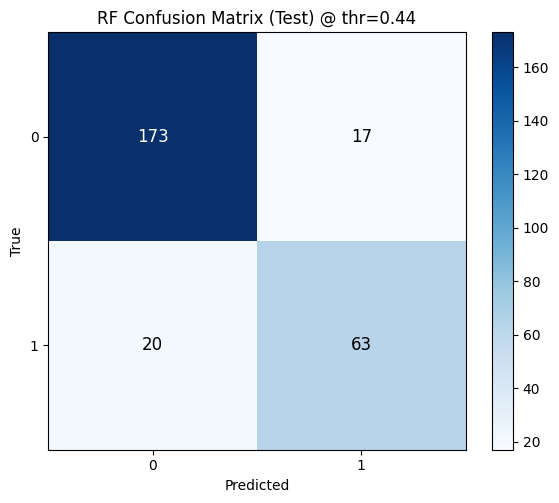

In [ ]:
# --- Confusion Matrix Plot (Blue style like your LSTM figure) ---
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues", interpolation="nearest")

# Title (match LSTM style)
ax.set_title(f"RF Confusion Matrix (Test) @ thr={best_thr:.2f}")

# Axis labels + ticks
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["0", "1"])
ax.set_yticklabels(["0", "1"])

# Colorbar (same vibe as your LSTM)
fig.colorbar(im, ax=ax)

# Annotate counts with contrasting text color
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12
        )

# Clean layout
ax.set_aspect("equal")
plt.tight_layout()
plt.show()
